In [1]:
""" Imports and Setup. """
import sys
import pandas as pd
import numpy as np
sys.path.append("/Users/emilieyu/endotehelial-masboss")
import matplotlib.pyplot as plt
import copy


from src.config import load_spatial_config
from src.paths import BM_RESULTS_DIR

CFG = load_spatial_config()

from abm.flow_field import FlowField
from abm.endothelial_cell import EndothelialCell
from abm.membrane_node import MembraneNode
from abm.rho_lookup_table import RhoLookupTable
from abm.abm_helpers import classify_phenotype
from abm.simulation import run_sim

lut  = RhoLookupTable(CFG, BM_RESULTS_DIR)
flow = FlowField(magnitude=CFG['mechanics'].get('f_magnitude', 3.0))
cell = EndothelialCell(
    cell_id=0,
    centroid=np.array([0.0, 0.0]),
    lut=lut,
    cfg=CFG,
    n_nodes=12,
    radius=10.0,
    flow_direction=flow.direction
)


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437


In [2]:
""" MOCK LUT CLASS FOR CHECK """
class PassiveLUT:
    rhoa_rest = 0.463
    rhoc_rest = 0.437
    def query(self, dsp, tjp1, jcad):
        return self.rhoa_rest, self.rhoc_rest

### Preparation Checks: with 16 nodes

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437
n_nodes:      16
radius:       12 units = 36 µm
rest_length:  4.682 units = 14.0 µm
target_area:  440.9 units² = 3968 µm²
n_upstream:   1
n_downstream: 1
n_lateral:    14
lateral springs: 12
polar springs:   4


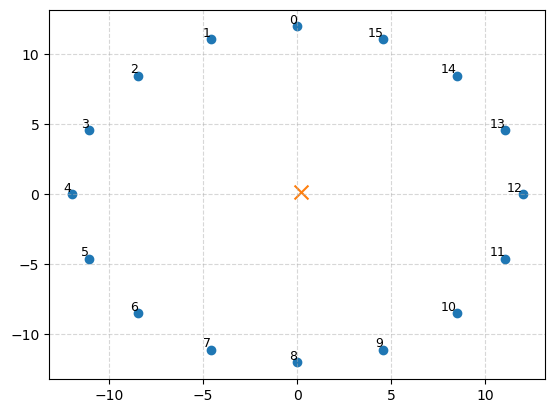

In [2]:
lut  = RhoLookupTable(CFG, BM_RESULTS_DIR)
cell = EndothelialCell(
    cell_id=0,
    centroid=np.array([0.0, 0.0]),
    lut=lut, cfg=CFG,
    n_nodes=CFG['sim']['n_nodes'],
    radius=CFG['sim']['radius'],
    flow_direction=np.array([1.0, 0.0])
)

print(f"n_nodes:      {cell.n_nodes}")
print(f"radius:       {CFG['sim']['radius']} units = {CFG['sim']['radius']*3} µm")
print(f"rest_length:  {cell.rest_length:.3f} units = {cell.rest_length*3:.1f} µm")
print(f"target_area:  {cell.target_area:.1f} units² = {cell.target_area*9:.0f} µm²")
print(f"n_upstream:   {sum(1 for n in cell.nodes if n.role=='upstream')}")
print(f"n_downstream: {sum(1 for n in cell.nodes if n.role=='downstream')}")
print(f"n_lateral:    {sum(1 for n in cell.nodes if n.role=='lateral')}")

lateral, polar = cell._spring_populations()
print(f"lateral springs: {len(lateral)}")
print(f"polar springs:   {len(polar)}")

pos = cell.positions
x, y = pos[:, 0], pos[:, 1]
c = cell.centroid

plt.figure()
plt.scatter(x, y)
for node, (xi, yi) in zip(cell.nodes, pos):
    plt.text(xi, yi, str(node.id), fontsize=9, ha='right', va='bottom')

plt.scatter(c[0]+0.2, c[1]+0.2, marker='x', s=100)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
plt.close()

## Passive Rho vs Flow Check

In [6]:
# --- Simulation 1: Full model (Rho active) ---
flow = FlowField(magnitude=CFG['mechanics']['f_magnitude'])
cell_rho = EndothelialCell(0, np.array([0.0, 0.0]),
                           lut=lut, cfg=CFG,
                           n_nodes=CFG['sim']['n_nodes'],
                           radius=CFG['sim']['radius'], 
                           flow_direction=flow.direction)

for _ in range(500):
    cell_rho.step(flow, dt=CFG['sim']['dt'])
s_rho = cell_rho.get_state()

In [ ]:

# --- Simulation 2: Passive cell (Rho disabled) ---
# Replace LUT with one that always returns rest values

cell_passive = EndothelialCell(0, np.array([0.0, 0.0]),
                               lut=PassiveLUT(), cfg=CFG,
                               n_nodes=CFG['sim']['n_nodes'],
                               radius=CFG['sim']['radius'], 
                               flow_direction=flow.direction)
for _ in range(500):
    cell_passive.step(flow, dt=CFG['sim']['dt'])
s_passive = cell_passive.get_state()


In [7]:

# --- Print comparison ---
print(f"{'':>20} {'AR':>6} {'k_active':>9} {'lsf':>6} {'t_sf':>7}")
print(f"{'Full model (Rho)':>20} "
      f"{s_rho['metrics']['ar']:>6.3f} "
      f"{s_rho['remodelling']['mean_k_active']:>9.3f} "
      f"{s_rho['remodelling']['mean_lsf_ratio']:>6.3f} "
      f"{s_rho['mechanics']['t_sf']:>7.4f}")
print(f"{'Passive (no Rho)':>20} "
      f"{s_passive['metrics']['ar']:>6.3f} "
      f"{s_passive['remodelling']['mean_k_active']:>9.3f} "
      f"{s_passive['remodelling']['mean_lsf_ratio']:>6.3f} "
      f"{s_passive['mechanics']['t_sf']:>7.4f}")

ar_diff = s_rho['metrics']['ar'] - s_passive['metrics']['ar']
print(f"\nAR difference (Rho contribution): {ar_diff:+.3f}")
print(f"Rho contribution as % of passive AR: "
      f"{ar_diff/s_passive['metrics']['ar']*100:+.1f}%")


                         AR  k_active    lsf    t_sf
    Full model (Rho)  2.244     1.368  0.859  0.7457
    Passive (no Rho)  2.356     1.000  1.000  0.5244

AR difference (Rho contribution): -0.112
Rho contribution as % of passive AR: -4.8%


In [8]:
passive_ar = s_passive['metrics']['ar']
print(f"Passive baseline AR: {passive_ar:.3f}\n")

conditions = {
    'WT':      CFG,
    'DSP-KO':  {**copy.deepcopy(CFG),
                'hill_params': {**copy.deepcopy(CFG['hill_params']),
                'DSP':  {**CFG['hill_params']['DSP'],  'knocked_out': True}}},
    'TJP1-KO': {**copy.deepcopy(CFG),
                'hill_params': {**copy.deepcopy(CFG['hill_params']),
                'TJP1': {**CFG['hill_params']['TJP1'], 'knocked_out': True}}},
            
}

for name, cfg in conditions.items():
    flow = FlowField(magnitude=cfg['mechanics']['f_magnitude'])
    cell = EndothelialCell(0, np.array([0.0, 0.0]),
                           lut=lut, cfg=cfg,
                           n_nodes=CFG['sim']['n_nodes'],
                           radius=CFG['sim']['radius'], 
                           flow_direction=flow.direction)
    for _ in range(500):
        cell.step(flow, dt=cfg['sim']['dt'])
    s = cell.get_state()
    diff = s['metrics']['ar'] - passive_ar
    print(f"{name:<10}: AR={s['metrics']['ar']:.3f} | "
          f"vs passive={diff:+.3f} | "
          f"k={s['remodelling']['mean_k_active']:.3f} | "
          f"lsf={s['remodelling']['mean_lsf_ratio']:.3f}")


Passive baseline AR: 2.356

WT        : AR=2.244 | vs passive=-0.112 | k=1.368 | lsf=0.859
DSP-KO    : AR=2.255 | vs passive=-0.101 | k=1.000 | lsf=0.784
TJP1-KO   : AR=2.254 | vs passive=-0.102 | k=1.779 | lsf=1.000


In [10]:
# Step-by-step AR breakdown
for name, cfg in conditions.items():
    cell = EndothelialCell(0, np.array([0.0, 0.0]),
                           lut=lut, cfg=cfg,
                           n_nodes=CFG['sim']['n_nodes'],
                           radius=CFG['sim']['radius'], 
                           flow_direction=flow.direction)
    flow = FlowField(magnitude=cfg['mechanics']['f_magnitude'])
    for _ in range(500):
        cell.step(flow, dt=cfg['sim']['dt'])
    
    lateral, polar = cell._spring_populations()
    lat_tension = np.mean([s.tension_total for s in lateral])
    lat_k       = np.mean([s.k_active for s in lateral])
    lat_lsf     = np.mean([s.L_sf/s.L_cortex for s in lateral])
    lat_rhoa    = np.mean([s.P_RhoA for s in lateral])
    lat_rhoc    = np.mean([s.P_RhoC for s in lateral])
    
    s = cell.get_state()
    print(f"{name:<10}: AR={s['metrics']['ar']:.3f} | "
          f"lat_T={lat_tension:.3f} | "
          f"lat_k={lat_k:.3f} | "
          f"lat_lsf={lat_lsf:.3f} | "
          f"lat_RhoA={lat_rhoa:.3f} | "
          f"lat_RhoC={lat_rhoc:.3f}")

WT        : AR=2.244 | lat_T=2.328 | lat_k=1.349 | lat_lsf=0.859 | lat_RhoA=0.633 | lat_RhoC=0.630
DSP-KO    : AR=2.255 | lat_T=2.119 | lat_k=1.000 | lat_lsf=0.784 | lat_RhoA=0.270 | lat_RhoC=0.777
TJP1-KO   : AR=2.254 | lat_T=2.426 | lat_k=1.742 | lat_lsf=1.000 | lat_RhoA=0.785 | lat_RhoC=0.268


In [14]:
for f in [11.0, 12.0, 13.0]:
    results = {}
    passive_cell = EndothelialCell(0, np.array([0.0, 0.0]),
                                   lut=PassiveLUT(), cfg=CFG,
                                   n_nodes=CFG['sim']['n_nodes'],
                                   radius=CFG['sim']['radius'], flow_direction=flow.direction)
    passive_flow = FlowField(magnitude=f)
    for _ in range(500):
        passive_cell.step(passive_flow, dt=CFG['sim']['dt'])
    passive_ar = passive_cell.get_state()['metrics']['ar']

    for name, cfg in conditions.items():
        c = copy.deepcopy(cfg)
        c['mechanics']['f_magnitude'] = f
        cell = EndothelialCell(0, np.array([0.0, 0.0]),
                               lut=lut, cfg=c,
                               n_nodes=CFG['sim']['n_nodes'],
                               radius=CFG['sim']['radius'],
                               flow_direction=flow.direction)
        flow = FlowField(magnitude=f)
        for _ in range(500):
            cell.step(flow, dt=CFG['sim']['dt'])
        s = cell.get_state()
        results[name] = s['metrics']['ar']

    print(f"f={f}: passive={passive_ar:.3f} | "
          f"TJP1-KO={results['TJP1-KO']:.3f} | "
          f"WT={results['WT']:.3f} | "
          f"DSP-KO={results['DSP-KO']:.3f}")

f=11.0: passive=6.313 | TJP1-KO=4.952 | WT=5.297 | DSP-KO=5.986
f=12.0: passive=6.862 | TJP1-KO=5.297 | WT=5.706 | DSP-KO=6.515
f=13.0: passive=7.425 | TJP1-KO=5.645 | WT=6.122 | DSP-KO=7.058


## SIM RUN FROM SCRIPT

In [3]:
""" Perturbation Configs """
conditions = {
    'WT': None,
    'DSP_KO': {'DSP': {'knocked_out': True}},
    'DSP_JCAD_DKO': {'DSP': {'knocked_out': True}, 'JCAD': {'knocked_out': True}},
    'TJP1_KO': {'TJP1': {'knocked_out': True}},
    'TJP1_JCAD_DKO':  {'TJP1': { 'knocked_out': True}, 'JCAD': {'knocked_out': True}}
}


  WT  (500 steps, f=12)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.008      0.0°  -0.026  1.000  1.000  0.0000  1.008
   100  2.295    180.0°  +0.013  1.099  0.974  0.6658  1.001
   200  3.823    180.0°  -0.007  1.271  0.916  1.3243  0.998
   300  4.959    180.0°  -0.007  1.400  0.872  1.8073  0.996
   400  5.551    180.0°  -0.007  1.492  0.841  2.0705  0.995
   499  5.779    180.0°  -0.007  1.557  0.819  2.1905  0.995

--- Spring state at step 500 ---
 id      pop   align   T_tot  T_cort   T_sf      k    lsf   RhoA   RhoC
  0  lateral   0.981  10.101   6.521  3.581  1.528  0.782  0.644  0.637
  1  lateral   0.831   9.115   6.273  2.842  1.546  0.809  0.644  0.637
  2  lateral   0.556   8.038   6.270  1.767  1.571  0.868  0.644  0.637
  3    polar   0.195   6.945   6.374  0.572  1.583  0.953  0.644  0.637
  4    polar   0.195   6.945   6.374  0.572  1.583  0.953  0.644  0.637
  5  lateral   0.556   8.038   6.270  1.767  1.571  0.868  0.644  0.637
  6  latera

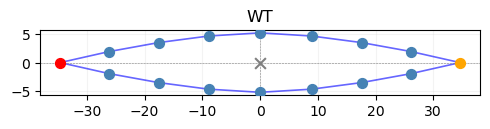

In [4]:
wt = run_sim(CFG, lut, label='WT', n_steps=500, print_every=100, plot=True)



  DSP-KO  (500 steps, f=12)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.008      0.0°  -0.026  1.000  1.000  0.0000  1.008
   100  2.340    180.0°  +0.465  1.000  0.957  0.7100  1.002
   200  3.976    180.0°  +0.541  1.000  0.874  1.4503  0.999
   300  5.349    180.0°  +0.541  1.000  0.815  2.0353  0.997
   400  6.271    180.0°  +0.541  1.000  0.772  2.4191  0.996
   499  6.828    180.0°  +0.541  1.000  0.742  2.6524  0.996

--- Spring state at step 500 ---
 id      pop   align   T_tot  T_cort   T_sf      k    lsf   RhoA   RhoC
  0  lateral   0.981   8.717   4.705  4.012  1.000  0.738  0.261  0.802
  1  lateral   0.831   8.037   4.645  3.391  1.000  0.729  0.261  0.802
  2  lateral   0.556   7.374   5.018  2.356  1.000  0.759  0.261  0.802
  3    polar   0.195   6.762   5.912  0.850  1.000  0.914  0.261  0.802
  4    polar   0.195   6.762   5.912  0.850  1.000  0.914  0.261  0.802
  5  lateral   0.556   7.374   5.018  2.356  1.000  0.759  0.261  0.802
  6  la

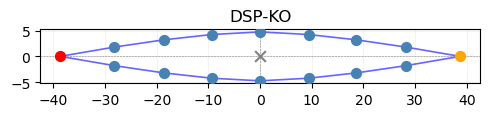

In [5]:
dsp = run_sim(CFG, lut, label='DSP-KO', n_steps=500,
              conditions_override=conditions['DSP_KO'], plot=True)

In [6]:
passive = run_sim(CFG, PassiveLUT(), label='Passive', n_steps=500)


  Passive  (500 steps, f=12)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.008      0.0°  -0.026  1.000  1.000  0.0000  1.008
   100  2.255    180.0°  -0.026  1.000  1.000  0.6009  1.002
   200  3.797    180.0°  -0.026  1.000  1.000  1.1518  0.999
   300  5.170    180.0°  -0.026  1.000  1.000  1.6203  0.998
   400  6.152    180.0°  -0.026  1.000  1.000  1.9403  0.997
   499  6.788    180.0°  -0.026  1.000  1.000  2.1383  0.996

--- Spring state at step 500 ---
 id      pop   align   T_tot  T_cort   T_sf      k    lsf   RhoA   RhoC
  0  lateral   0.981   7.978   4.758  3.220  1.000  1.000  0.463  0.437
  1  lateral   0.831   7.381   4.690  2.691  1.000  1.000  0.463  0.437
  2  lateral   0.556   6.825   4.934  1.891  1.000  1.000  0.463  0.437
  3    polar   0.195   6.332   5.581  0.751  1.000  1.000  0.463  0.437
  4    polar   0.195   6.332   5.581  0.751  1.000  1.000  0.463  0.437
  5  lateral   0.556   6.825   4.934  1.891  1.000  1.000  0.463  0.437
  6  l

In [7]:
# Quick comparison
print(f"\nAR summary:")
for r in [passive, wt, dsp]:
    ar  = r['final']['metrics']['ar']
    bal = r['final']['signalling']['rho_balance']
    print(f"  {r['label']:<12}: AR={ar:.3f}  balance={bal:+.3f}")


AR summary:
  Passive     : AR=6.788  balance=-0.026
  WT          : AR=5.779  balance=-0.007
  DSP-KO      : AR=6.828  balance=+0.541


In [8]:
""" Diagnostic """
# What protrusion force is actually being applied?
flow = FlowField(magnitude=CFG['mechanics']['f_magnitude'])

cfg_dsp = copy.deepcopy(CFG)
cfg_dsp['hill_params']['DSP']['knocked_out'] = True
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=cfg_dsp,
                       n_nodes=CFG['sim']['n_nodes'],
                       radius=CFG['sim']['radius'], 
                       flow_direction=flow.direction)
for _ in range(500):
    cell.step(flow, dt=CFG['sim']['dt'])

gain = CFG['mechanics'].get('rhoc_protrusion_gain', 2.0)
for node in cell.nodes:
    if node.role not in ('upstream', 'downstream'):
        continue
    neighbours = [s for s in cell.springs
                  if s.node_1 is node or s.node_2 is node]
    delta_rhoc = float(np.mean([
        max(s.P_RhoC - cell.lut.rhoc_rest, 0.0)
        for s in neighbours
    ]))
    protrusion_force = gain * delta_rhoc
    print(f"node {node.id} ({node.role}): "
          f"delta_rhoC={delta_rhoc:.4f} "
          f"protrusion_force={protrusion_force:.4f} "
          f"vs pole_force={CFG['mechanics']['f_magnitude']}")

node 4 (upstream): delta_rhoC=0.3650 protrusion_force=0.0730 vs pole_force=12
node 12 (downstream): delta_rhoC=0.3650 protrusion_force=0.0730 vs pole_force=12


## Run All Conditions

In [3]:
conditions = {
    'Passive':       {'lut': PassiveLUT()},
    'WT':            {},
    'DSP-KO':        {'DSP':  {'knocked_out': True}},
    'TJP1-KO':       {'TJP1': {'knocked_out': True}},
    'DSP-JCAD-DKO':  {'DSP':  {'knocked_out': True}, 
                      'JCAD': {'knocked_out': True}},
    'TJP1-JCAD-DKO': {'TJP1': {'knocked_out': True},
                      'JCAD': {'knocked_out': True}},
}

print(f"{'Condition':<18} {'AR':>6} {'vs_passive':>11} "
      f"{'balance':>8} {'k':>6} {'lsf':>6}")
passive_ar = None

for name, overrides in conditions.items():
    use_lut = overrides.pop('lut', lut)
    result  = run_sim(CFG, use_lut, label=name,
                      n_steps=500, print_every=500, plot=False, print_spring=False,
                      conditions_override=overrides if overrides else None)
    ar  = result['final']['metrics']['ar']
    bal = result['final']['signalling']['rho_balance']
    k   = result['final']['remodelling']['mean_k_active']
    lsf = result['final']['remodelling']['mean_lsf_ratio']

    if name == 'Passive':
        passive_ar = ar

    diff = ar - passive_ar if passive_ar else 0
    print(f"{name:<18} {ar:>6.3f} {diff:>+11.3f} "
          f"{bal:>+8.3f} {k:>6.3f} {lsf:>6.3f}")

Condition              AR  vs_passive  balance      k    lsf

  Passive  (500 steps, f=10)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.007      0.0°  -0.026  1.000  1.000  0.0000  1.007
   499  7.035    180.0°  -0.026  1.000  1.000  0.0000  0.998
Passive             7.035      +0.000   -0.026  1.000  1.000

  WT  (500 steps, f=10)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.007      0.0°  -0.026  1.000  1.000  0.0000  1.007
   499  4.806    180.0°  -0.007  1.946  0.855  1.7881  0.994
WT                  4.806      -2.229   -0.007  1.946  0.855

  DSP-KO  (500 steps, f=10)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.007      0.0°  -0.026  1.000  1.000  0.0000  1.007
   499  6.145    180.0°  +0.541  1.000  0.740  2.4579  0.996
DSP-KO              6.145      -0.890   +0.541  1.000  0.740

  TJP1-KO  (500 steps, f=10)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.007      0.0°  -0.026  1.0

Pole forces push poles apart
→ cell elongates along flow axis
→ lateral springs stretch (L_current > L_cortex)
→ cortical tension rises on lateral springs
→ lateral springs pull lateral nodes inward slightly
→ area drops below target
→ pressure pushes all nodes outward
→ polar nodes pushed further out (they have less spring resistance)
→ AR stabilises at equilibrium between pole force and cortical restoring force

In [4]:
for dt_test in [0.1, 0.5, 1.0, 2.0]:
    result = run_sim(CFG, lut, label=f'WT dt={dt_test}',
                     n_steps=int(500/dt_test),
                     print_every=int(100/dt_test))
    ar  = result['final']['metrics']['ar']
    ae  = result['final']['metrics']['area_err']
    print(f"dt={dt_test}: AR={ar:.3f}  area_err={ae:.3f}")


  WT dt=0.1  (5000 steps, f=10)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.007      0.0°  -0.026  1.000  1.000  0.0000  1.007
  1000  4.458      0.0°  -0.007  2.207  0.815  1.7435  0.994
  2000  4.327      0.0°  -0.007  2.265  0.806  1.7132  0.994
  3000  4.322      0.0°  -0.007  2.267  0.805  1.7122  0.994
  4000  4.322      0.0°  -0.007  2.267  0.805  1.7122  0.994
  4999  4.322    180.0°  -0.007  2.267  0.805  1.7122  0.994
dt=0.1: AR=4.322  area_err=0.994

  WT dt=0.5  (1000 steps, f=10)
  step     AR   orient     bal      k    lsf    t_sf   area
     0  1.007      0.0°  -0.026  1.000  1.000  0.0000  1.007
   200  3.371    180.0°  -0.007  1.396  0.941  1.1084  0.998
   400  4.718    180.0°  -0.007  1.821  0.875  1.7183  0.995
   600  4.755      0.0°  -0.007  2.038  0.841  1.7982  0.994
   800  4.581      0.0°  -0.007  2.150  0.824  1.7702  0.994
   999  4.459      0.0°  -0.007  2.207  0.815  1.7436  0.994
dt=0.5: AR=4.459  area_err=0.994

  WT dt=1.0  (5